In [22]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import glob
import os
import pandas as pd

from create_figs import create_m8_map

import warnings
warnings.filterwarnings("ignore")

This notebook takes a list of files and computes an M8 maps for each.

In [ ]:
source_info = pd.read_csv("../data/source_info.csv")
source_info.set_index('Main', inplace=True)
files = glob.glob("/Volumes/Alpha/Research/data/*/*12co.fits")
overwrite = True

INFO: Auto-setting vmin to -9.565e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.471e-01 [aplpy.core]
INFO: Auto-setting vmin to  3.255e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.356e-01 [aplpy.core]
one
one
one
one
one


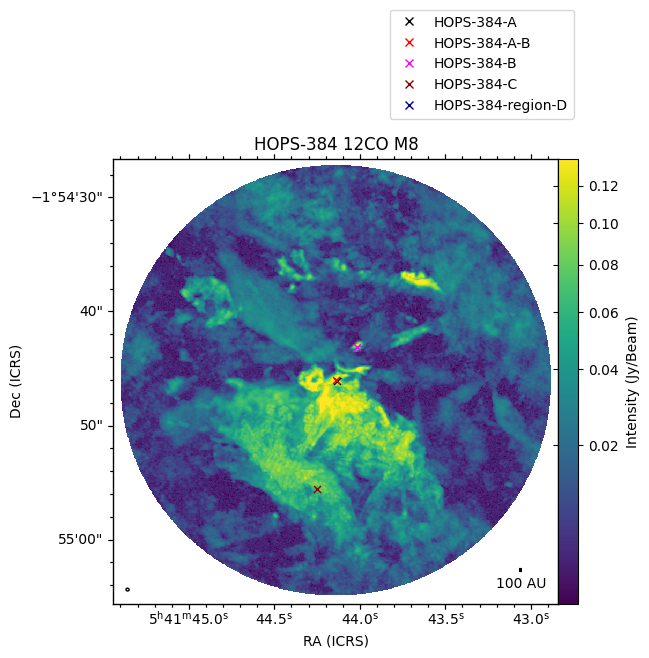

In [ ]:
for file in files:

    target_name = os.path.basename(file.split("__")[0].upper())
    output_path = f"../results/m8_maps/{target_name}_m8.png"

    # verify output path exists and
    # skip already existing files if you don't want to overwrite them
    if (os.path.exists(output_path)) and (not overwrite):
        continue

    try:
        target_info = source_info.loc[target_name]

        hdulist = fits.open(file)
        hdu = hdulist[0]

        # extract center coords
        center_ra = hdu.header['OBSRA']
        center_dec = hdu.header['OBSDEC']

        # set center and size of cutout
        center = SkyCoord(center_ra, center_dec, unit=u.degree)
        size = np.array([39, 39]) * u.arcsecond

        fig = create_m8_map(hdu, center, size, distance=target_info.iloc[0]['Dis'])
        fig.set_title(f"{target_name} 12CO M8")
        fig.show_colorscale(cmap='viridis', stretch='sqrt')

        # add a marker at each source
        marker_colors = ['black', 'red', 'magenta', 'darkred', 'darkblue']
        legend_handles = []
        for i, row in target_info.reset_index().iterrows():
            # only mark first 4 sources
            if i > 3:
                continue
            print("one")
            center2 = SkyCoord(row['RA'], row['Dec'], unit=u.degree)
            fig.show_markers(center2.ra.deg, center2.dec.deg, coords_frame='world', marker='x', s=25, c=marker_colors[i], linewidths=1, label=row['Source'])

            # Create legend handle for this source (only if not already added)
            legend_handles.append(mlines.Line2D([], [], color=marker_colors[i], marker='x', markersize=6, linestyle='None', label=row['Source']))
        fig.ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.05,1.35))

        fig.savefig(output_path)

    except Exception as error:
        print(f"Error for {target_name}, {error}")